In [ ]:
import pandas as pd
#CreatingasimpleSeries
data= [10,20,30,40]
series =pd.Series(data)
print(series)

0    10
1    20
2    30
3    40
dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
series = pd.Series([10,20,30])
print(series.index)
#Output:RangeIndex(start=0,stop=3,step=1)
#User Defined:
series = pd.Series([10,20,30],index=['a','b','c'])
print(series)
#Output:
#a10
#b20
#c30
#datestimeindex
dates=pd.date_range('2023-01-01',periods=3)
series = pd.Series([10,20,30],index=dates)
print(series)
print(series.index)
#SetorResetIndex
series.index=['x','y','z']#Series
#ForDataFrame
df=pd.DataFrame({'A':[1,2]},index=['row1','row2'])
df.reset_index(inplace=True)

RangeIndex(start=0, stop=3, step=1)
a    10
b    20
c    30
dtype: int64
2023-01-01    10
2023-01-02    20
2023-01-03    30
Freq: D, dtype: int64
DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03'], dtype='datetime64[ns]', freq='D')


In [ ]:
import pandas as pd
import os

def analyze_bank_data():
    # Filepath for the input dataset
    input_file = 'bank.csv'

    # Check if file exists before proceeding (good practice)
    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found in the current directory.")
        return

    # 1. Load the provided dataset and import in pandas DataFrame
    print("--- Task 1: Loading Data ---")
    try:
        df = pd.read_csv(input_file)
        print("Data loaded successfully.")
        print(f"Shape: {df.shape}")
        print("-" * 30)
    except Exception as e:
        print(f"Error loading file: {e}")
        return

    # 2. Check info of the DataFrame
    print("\n--- Task 2: Inspection ---")

    # (a) Columns with dtypes=object
    object_columns = df.select_dtypes(include=['object']).columns
    print(f"(a) Columns with object dtype:\n{list(object_columns)}")
    print("-" * 30)

    # (b) Unique values of those columns
    print("(b) Unique values for object columns:")
    for col in object_columns:
        unique_vals = df[col].unique()
        print(f" -> {col} ({len(unique_vals)} unique): {unique_vals}")
    print("-" * 30)

    # (c) Check for the total number of null values in each column
    print("(c) Null values per column:")
    null_counts = df.isnull().sum()
    # Filtering to show only columns with nulls if the list is long,
    # but for completeness, we show all as requested.
    print(null_counts)
    print("=" * 40)

    # 3. Drop object columns, store in new DF, and write to CSV
    print("\n--- Task 3: Filtering and Saving ---")

    # Create new DataFrame with only numeric columns
    # We use select_dtypes(exclude=['object']) to drop object columns automatically
    df_numeric = df.select_dtypes(exclude=['object'])

    output_file = 'banknumericdata.csv'
    df_numeric.to_csv(output_file, index=False)

    print(f"Object columns dropped.")
    print(f"Numeric data saved to '{output_file}'.")
    print(f"New shape: {df_numeric.shape}")
    print("=" * 40)

    # 4. Read 'banknumericdata.csv' and Find the summary statistics
    print("\n--- Task 4: Reading New File & Summary Statistics ---")

    if os.path.exists(output_file):
        df_new = pd.read_csv(output_file)

        print(f"Loaded '{output_file}' successfully.")
        print("Summary Statistics (describe):")
        print(df_new.describe())
    else:
        print(f"Error: Could not find '{output_file}' to read.")

if __name__ == "__main__":
    analyze_bank_data()

--- Task 1: Loading Data ---
Data loaded successfully.
Shape: (45211, 17)
------------------------------

--- Task 2: Inspection ---
(a) Columns with object dtype:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
------------------------------
(b) Unique values for object columns:
 -> job (12 unique): ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
 -> marital (3 unique): ['married' 'single' 'divorced']
 -> education (4 unique): ['tertiary' 'secondary' 'unknown' 'primary']
 -> default (2 unique): ['no' 'yes']
 -> housing (2 unique): ['yes' 'no']
 -> loan (2 unique): ['no' 'yes']
 -> contact (3 unique): ['unknown' 'cellular' 'telephone']
 -> month (12 unique): ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
 -> poutcome (4 unique): ['unknown' 'failure' 'other' 'success']
 -> y (2 unique): ['no' 'yes']
----------

In [ ]:
import pandas as pd
import os

def clean_and_impute_data():
    # Filepath for the input dataset
    # Note: Using the actual filename found in the upload 'medical_students_dataset.csv'
    input_file = 'medical_students_dataset.csv'

    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found.")
        return

    # 1. Load the provided dataset
    print("--- Task 1: Loading Data ---")
    df = pd.read_csv(input_file)
    print(f"Data loaded. Shape: {df.shape}")
    print("-" * 30)

    # 2. Check info and identify columns with missing values
    print("\n--- Task 2: Inspection & Missing Values ---")
    print("Dataset Info:")
    print(df.info())
    print("\nNull Values per Column:")
    null_counts = df.isnull().sum()
    columns_with_nulls = null_counts[null_counts > 0]
    print(columns_with_nulls)
    print("-" * 30)

    # 3. Impute missing values
    print("\n--- Task 3: Imputation ---")

    # We will iterate through columns with nulls and apply specific strategies
    for col in columns_with_nulls.index:
        dtype = df[col].dtype
        missing_count = df[col].isnull().sum()

        # Strategy for Numeric Columns (float/int)
        if dtype in ['float64', 'int64']:
            # Using Median: Robust against outliers which are common in medical data (e.g., weight, heart rate)
            fill_value = df[col].median()
            df[col] = df[col].fillna(fill_value)
            print(f"Column '{col}': Filled {missing_count} missing values with Median ({fill_value:.2f}).")
            print(f"   Reason: Numeric data often has outliers; Median is more robust than Mean.")

        # Strategy for Categorical Columns (object)
        else:
            # Using Mode: The most frequent category is statistically the safest guess for categorical data
            if len(df[col].mode()) > 0:
                fill_value = df[col].mode()[0]
                df[col] = df[col].fillna(fill_value)
                print(f"Column '{col}': Filled {missing_count} missing values with Mode ('{fill_value}').")
                print(f"   Reason: For categorical data, replacing with the most frequent value (Mode) preserves the distribution.")
            else:
                # Fallback if mode cannot be calculated (empty column)
                df[col] = df[col].fillna("Unknown")
                print(f"Column '{col}': Filled with 'Unknown' (No mode found).")

    # Verify no nulls remain
    print(f"\nRemaining Nulls: {df.isnull().sum().sum()}")
    print("-" * 30)

    # 4. Check for and manage duplicate values
    print("\n--- Task 4: Duplicate Management ---")
    duplicate_count = df.duplicated().sum()
    print(f"Total duplicate rows found: {duplicate_count}")

    if duplicate_count > 0:
        initial_shape = df.shape
        df.drop_duplicates(inplace=True)
        final_shape = df.shape
        print(f"Duplicates removed. Shape changed from {initial_shape} to {final_shape}.")
    else:
        print("No duplicates to remove.")

    print("=" * 40)
    print("Data cleaning completed successfully.")

if __name__ == "__main__":
    clean_and_impute_data()

--- Task 1: Loading Data ---
Data loaded. Shape: (200000, 13)
------------------------------

--- Task 2: Inspection & Missing Values ---
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Student ID      180000 non-null  float64
 1   Age             180000 non-null  float64
 2   Gender          180000 non-null  object 
 3   Height          180000 non-null  float64
 4   Weight          180000 non-null  float64
 5   Blood Type      180000 non-null  object 
 6   BMI             180000 non-null  float64
 7   Temperature     180000 non-null  float64
 8   Heart Rate      180000 non-null  float64
 9   Blood Pressure  180000 non-null  float64
 10  Cholesterol     180000 non-null  float64
 11  Diabetes        180000 non-null  object 
 12  Smoking         180000 non-null  object 
dtypes: float64(9), object(4)
memory usage: 19.

In [ ]:
import pandas as pd
import os

def analyze_titanic_fare():
    # Filepath for the input dataset
    input_file = 'Titanic-Dataset.csv'

    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found.")
        return

    # 1. Load the dataset
    print("--- Loading Data ---")
    try:
        df = pd.read_csv(input_file)
        print("Data loaded successfully.")
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    # 2. Subset for specific columns
    required_columns = ['Name', 'Pclass', 'Sex', 'Age', 'Fare', 'Survived']
    # Check if all columns exist
    if not set(required_columns).issubset(df.columns):
        print(f"Error: Dataset is missing one of the required columns: {required_columns}")
        return

    df_subset = df[required_columns]
    print(f"Subsetted DataFrame created with columns: {required_columns}")

    # 3. Retain only rows where 'Pclass' is equal to 1 (First-class)
    df_first_class = df_subset[df_subset['Pclass'] == 1]
    print(f"Filtered for First Class (Pclass=1). Row count: {len(df_first_class)}")

    # 4. Calculate statistics for the 'Fare' column
    print("\n--- 'Fare' Statistics for First Class Passengers ---")

    fare_mean = df_first_class['Fare'].mean()
    fare_median = df_first_class['Fare'].median()
    fare_max = df_first_class['Fare'].max()
    fare_min = df_first_class['Fare'].min()

    print(f"Mean Fare:    {fare_mean:.4f}")
    print(f"Median Fare:  {fare_median:.4f}")
    print(f"Maximum Fare: {fare_max:.4f}")
    print(f"Minimum Fare: {fare_min:.4f}")

if __name__ == "__main__":
    analyze_titanic_fare()

--- Loading Data ---
Data loaded successfully.
Subsetted DataFrame created with columns: ['Name', 'Pclass', 'Sex', 'Age', 'Fare', 'Survived']
Filtered for First Class (Pclass=1). Row count: 216

--- 'Fare' Statistics for First Class Passengers ---
Mean Fare:    84.1547
Median Fare:  60.2875
Maximum Fare: 512.3292
Minimum Fare: 0.0000


In [ ]:
import pandas as pd
import os

def encode_embarked_column():
    # Filepath for the input dataset
    input_file = 'Titanic-Dataset.csv'

    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found.")
        return

    # 1. Load the provided dataset
    print("--- Loading Data ---")
    try:
        df = pd.read_csv(input_file)
        print(f"Original DataFrame Shape: {df.shape}")
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    # 2. Use one-hot encoding for the 'Embarked' column
    print("\n--- Task 1 & 2: One-Hot Encoding 'Embarked' ---")

    # Handle NaN values in 'Embarked' first, as get_dummies treats them as a separate category
    # For simplicity, we fill NaN with the most frequent value (Mode) before encoding.
    # The mode is typically 'S' (Southampton).
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # Fix FutureWarning

    # Use pandas get_dummies for one-hot encoding
    # We set drop_first=True to remove one dummy variable (e.g., 'Embarked_S') to avoid multicollinearity.
    # If all new columns are 0, it implicitly means the original value was 'S'.
    embarked_encoded = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True)

    # Add these new columns to the original DataFrame
    df = pd.concat([df, embarked_encoded], axis=1)

    print("One-hot encoding complete (using drop_first=True).")
    print(f"New DataFrame Shape: {df.shape}")

    # 3. Drop the original 'Embarked' column
    print("\n--- Task 3: Dropping Original Column ---")
    df.drop('Embarked', axis=1, inplace=True)
    print("Original 'Embarked' column dropped.")

    # 4. Print the first few rows of the modified DataFrame to verify the changes
    print("\n--- Task 4: Modified DataFrame Head (Verification) ---")
    # The verification columns are updated as 'Embarked_S' will be dropped due to drop_first=True
    # So, we should only expect 'Embarked_C' and 'Embarked_Q' to be explicitly present.
    verification_columns = ['Name', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked_C', 'Embarked_Q', 'Survived']

    # Check if all verification columns exist after processing
    if all(col in df.columns for col in verification_columns):
        print(df[verification_columns].head())
    else:
        print("Verification columns were not found as expected. Displaying full head instead.")
        print(df.head())

if __name__ == "__main__":
    encode_embarked_column()

--- Loading Data ---
Original DataFrame Shape: (891, 12)

--- Task 1 & 2: One-Hot Encoding 'Embarked' ---
One-hot encoding complete (using drop_first=True).
New DataFrame Shape: (891, 14)

--- Task 3: Dropping Original Column ---
Original 'Embarked' column dropped.

--- Task 4: Modified DataFrame Head (Verification) ---
Verification columns were not found as expected. Displaying full head instead.
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1 

--- Loading Data ---
DataFrame Shape: (891, 12)

--- Mean Survival Rate by Gender ---
Survival Rates:
Sex
female    0.742038
male      0.188908

Observation: The survival rate for females is significantly higher than for males.

--- Generating Visualization (Bar Plot) ---
Visualization saved as 'survival_by_gender_bar_plot.png'.


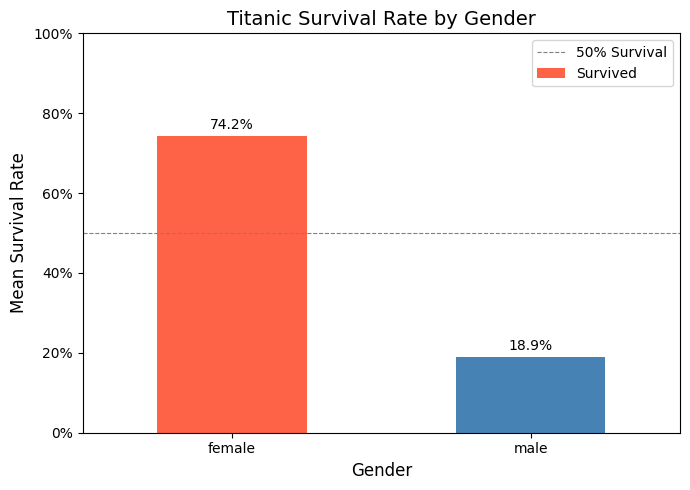

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def analyze_survival_by_gender():
    # Filepath for the input dataset
    input_file = 'Titanic-Dataset.csv'

    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found.")
        return

    # 1. Load the provided dataset
    print("--- Loading Data ---")
    try:
        df = pd.read_csv(input_file)
        print(f"DataFrame Shape: {df.shape}")
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    # 2. Compare the mean survival rates ('Survived') for different groups in the 'Sex' column.
    print("\n--- Mean Survival Rate by Gender ---")

    # The mean of the 'Survived' column (0 for perished, 1 for survived) gives the survival rate.
    survival_rates = df.groupby('Sex')['Survived'].mean().sort_values(ascending=False)

    print("Survival Rates:")
    print(survival_rates.to_string())
    print("\nObservation: The survival rate for females is significantly higher than for males.")

    # 3. Draw a visualization to show how the survival distributions vary by gender.
    print("\n--- Generating Visualization (Bar Plot) ---")

    # Create the visualization
    fig, ax = plt.subplots(figsize=(7, 5))

    # Bar plot of the calculated mean survival rates
    survival_rates.plot(
        kind='bar',
        ax=ax,
        color=['#FF6347', '#4682B4'] # Custom colors (e.g., coral for female, steel blue for male)
    )

    # Adding titles and labels for clarity
    ax.set_title('Titanic Survival Rate by Gender', fontsize=14)
    ax.set_ylabel('Mean Survival Rate', fontsize=12)
    ax.set_xlabel('Gender', fontsize=12)

    # Formatting y-axis as percentage (0.0 to 1.0)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=0)

    # Add a line indicating 50% survival for reference
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% Survival')

    # Add the exact mean values as text labels on top of the bars
    for i, rate in enumerate(survival_rates):
        ax.text(i, rate + 0.01, f'{rate:.1%}', ha='center', va='bottom', fontsize=10)

    ax.legend(loc='upper right')
    plt.tight_layout()

    # Save the plot (optional, but good for visualization tasks)
    plot_filename = 'survival_by_gender_bar_plot.png'
    plt.savefig(plot_filename)
    print(f"Visualization saved as '{plot_filename}'.")

    # Display the plot
    plt.show()

if __name__ == "__main__":
    analyze_survival_by_gender()

--- Loading Data ---
DataFrame Shape: (891, 12)
Missing 'Embarked' values filled with mode: S

--- Mean Survival Rate by Gender and Embarkation Port ---
Calculated Survival Rates:
   Sex Embarked  Survival Rate
female        C       0.876712
female        Q       0.750000
female        S       0.692683
  male        C       0.305263
  male        Q       0.073171
  male        S       0.174603

Observation: Female survival rates are consistently higher across all ports.
Interestingly, Cherbourg (C) has the highest overall survival rate.

--- Generating Visualization (Grouped Bar Plot) ---


/tmp/ipython-input-2046557391.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(mode_embarked, inplace=True)


Visualization saved as 'survival_by_gender_and_port_bar_plot.png'.


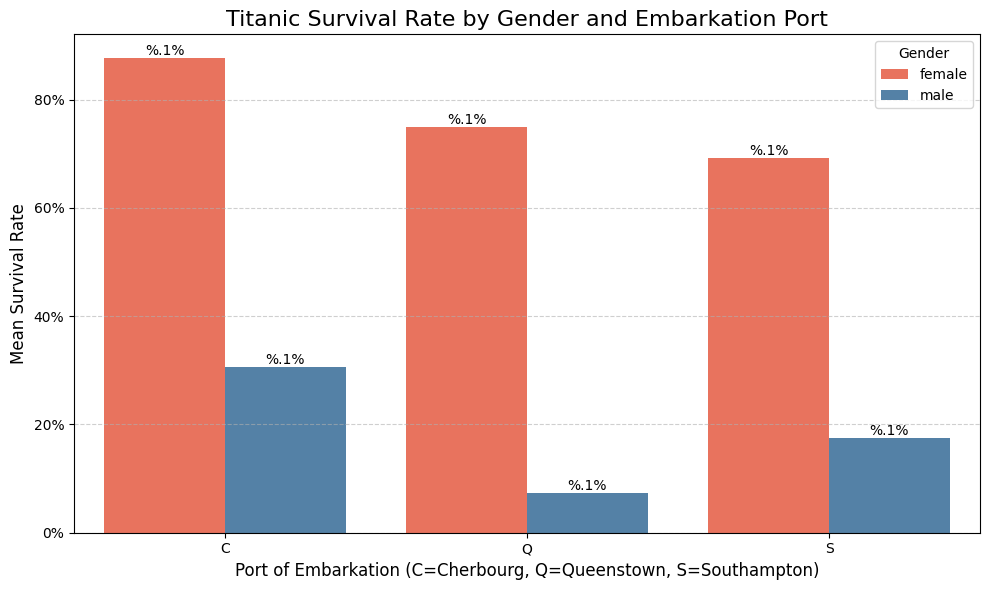

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def analyze_survival_by_gender_and_port():
    # Filepath for the input dataset
    input_file = 'Titanic-Dataset.csv'

    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found.")
        return

    # 1. Load the provided dataset
    print("--- Loading Data ---")
    try:
        df = pd.read_csv(input_file)
        print(f"DataFrame Shape: {df.shape}")
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    # Data Cleaning: Fill missing 'Embarked' values with the mode before grouping
    # This prevents the NaN group from appearing in the visualization
    if df['Embarked'].isnull().any():
        mode_embarked = df['Embarked'].mode()[0]
        df['Embarked'].fillna(mode_embarked, inplace=True)
        print(f"Missing 'Embarked' values filled with mode: {mode_embarked}")

    # 2. Calculate the mean survival rate grouped by both 'Sex' and 'Embarked'
    print("\n--- Mean Survival Rate by Gender and Embarkation Port ---")

    # Calculate the mean of 'Survived' for each combination of 'Sex' and 'Embarked'
    survival_rates_grouped = df.groupby(['Sex', 'Embarked'])['Survived'].mean().reset_index()

    # Rename 'Survived' column to 'Survival Rate' for clarity in printing
    survival_rates_grouped.rename(columns={'Survived': 'Survival Rate'}, inplace=True)

    print("Calculated Survival Rates:")
    print(survival_rates_grouped.to_string(index=False))
    print("\nObservation: Female survival rates are consistently higher across all ports.")
    print("Interestingly, Cherbourg (C) has the highest overall survival rate.")

    # 3. Draw a grouped visualization
    print("\n--- Generating Visualization (Grouped Bar Plot) ---")

    # Set up the plot using Seaborn for an effective grouped bar chart
    plt.figure(figsize=(10, 6))

    # Create the grouped bar plot
    # x-axis is 'Embarked' (ports), hue separates the bars by 'Sex'
    sns.barplot(
        data=survival_rates_grouped,
        x='Embarked',
        y='Survival Rate',
        hue='Sex',
        palette={'male': '#4682B4', 'female': '#FF6347'} # Steel Blue and Coral
    )

    # Add titles and labels
    plt.title('Titanic Survival Rate by Gender and Embarkation Port', fontsize=16)
    plt.xlabel('Port of Embarkation (C=Cherbourg, Q=Queenstown, S=Southampton)', fontsize=12)
    plt.ylabel('Mean Survival Rate', fontsize=12)

    # Formatting y-axis as percentage
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

    # Add data labels on the bars for precision
    for container in plt.gca().containers:
        plt.bar_label(container, fmt='%.1%')

    plt.legend(title='Gender')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Save the plot
    plot_filename = 'survival_by_gender_and_port_bar_plot.png'
    plt.savefig(plot_filename)
    print(f"Visualization saved as '{plot_filename}'.")

    # Display the plot
    plt.show()

if __name__ == "__main__":
    analyze_survival_by_gender_and_port()

--- Loading Data ---
DataFrame Shape: (891, 12)
Missing 'Age' values filled with median: 28.0

--- Creating Age Quantiles ---
Age column categorized into quantiles (Q1 to Q5).
Sample Age Distribution:
AgeGroup
Q1 (Youngest)    179
Q2               360
Q3               175
Q4 (Oldest)      177
Name: count, dtype: int64

--- Mean Survival Rate by Age Group and Class ---
Survival Rates (Rows=Age Group, Columns=Pclass):
               1st Class  2nd Class  3rd Class
AgeGroup                                      
Q1 (Youngest)      0.810      0.743      0.317
Q2                 0.607      0.397      0.241
Q3                 0.750      0.431      0.237
Q4 (Oldest)        0.535      0.400      0.078

Observation: In general, 1st Class passengers have the highest survival rates,
and the youngest age groups (Q1, Q2) tend to have higher survival within their classes.

--- Generating Visualization (Heatmap) ---
Visualization saved as 'survival_by_age_and_class_heatmap.png'.


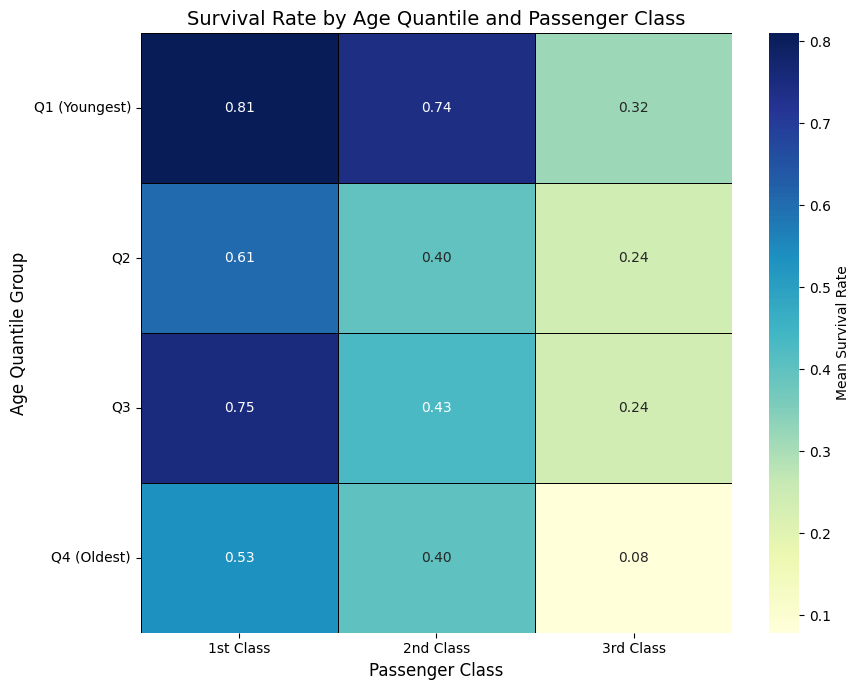

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def analyze_survival_by_age_and_class():
    # Filepath for the input dataset
    input_file = 'Titanic-Dataset.csv'

    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found.")
        return

    # 1. Load the provided dataset
    print("--- Loading Data ---")
    try:
        df = pd.read_csv(input_file)
        print(f"DataFrame Shape: {df.shape}")
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    # Data Cleaning: Handle missing 'Age' values
    # Since Age is critical for this analysis, we will fill missing values
    # with the median age, which is robust to outliers.
    if df['Age'].isnull().any():
        median_age = df['Age'].median()
        df['Age'] = df['Age'].fillna(median_age) # Fix FutureWarning
        print(f"Missing 'Age' values filled with median: {median_age:.1f}")

    # Data Preprocessing: Break up the 'Age' column into five quantiles
    print("\n--- Creating Age Quantiles ---")

    # Use pd.qcut to divide 'Age' into 5 equal-sized bins based on distribution (quantiles)
    # labels=False returns integer labels (0 to 4), which we then map to descriptive labels.
    # Added `duplicates='drop'` to handle cases where quantile edges are not unique.
    df['AgeGroup'] = pd.qcut(df['Age'], q=5, labels=False, duplicates='drop')

    # Create descriptive labels for better visualization (e.g., Q1, Q2, ..., Q5)
    # Adjust quantile_labels based on the actual number of unique bins created if duplicates='drop' was used.
    # For this specific case, it might create fewer than 5 unique bins, but we will adapt the labels.
    unique_age_groups = sorted(df['AgeGroup'].unique())
    num_bins = len(unique_age_groups)
    quantile_labels = {
        0: 'Q1 (Youngest)',
        1: 'Q2',
        2: 'Q3 (Median Age)',
        3: 'Q4',
        4: 'Q5 (Oldest)'
    }
    # Adapt labels if fewer than 5 bins are created by 'duplicates=drop'
    if num_bins < 5:
        new_labels = {}
        for i, bin_val in enumerate(unique_age_groups):
            if i == 0: new_labels[bin_val] = 'Q1 (Youngest)'
            elif i == num_bins - 1: new_labels[bin_val] = f'Q{num_bins} (Oldest)'
            else: new_labels[bin_val] = f'Q{i+1}'
        df['AgeGroup'] = df['AgeGroup'].map(new_labels)
    else:
        df['AgeGroup'] = df['AgeGroup'].map(quantile_labels)

    print("Age column categorized into quantiles (Q1 to Q5).")
    print(f"Sample Age Distribution:\n{df['AgeGroup'].value_counts().sort_index()}")

    # 2. Compare the means of 'Survived' by class and age group
    print("\n--- Mean Survival Rate by Age Group and Class ---")

    # Group by 'AgeGroup' and 'Pclass' and calculate the mean of 'Survived'
    survival_pivot = df.pivot_table(
        values='Survived',
        index='AgeGroup',      # Rows: Age Group
        columns='Pclass',      # Columns: Passenger Class
        aggfunc='mean'         # Value: Mean Survival Rate
    )

    # Rename columns for clarity (1, 2, 3 -> 1st, 2nd, 3rd)
    survival_pivot.columns = ['1st Class', '2nd Class', '3rd Class']

    # Print the resulting pivot table
    print("Survival Rates (Rows=Age Group, Columns=Pclass):")
    print(survival_pivot.to_string(float_format="{:.3f}".format))
    print("\nObservation: In general, 1st Class passengers have the highest survival rates,")
    print("and the youngest age groups (Q1, Q2) tend to have higher survival within their classes.")


    # 3. Draw a visualization using a heatmap
    print("\n--- Generating Visualization (Heatmap) ---")

    # Set up the plot using Seaborn for an effective heatmap
    plt.figure(figsize=(9, 7))

    # Create the heatmap
    sns.heatmap(
        survival_pivot,
        annot=True,              # Show the survival rate values on the map
        fmt=".2f",               # Format the annotations to two decimal places
        cmap="YlGnBu",           # Color palette (Yellow-Green-Blue gradient)
        linewidths=0.5,          # Lines between cells
        linecolor='black',
        cbar_kws={'label': 'Mean Survival Rate'} # Label for the color bar
    )

    # Add titles and labels
    plt.title('Survival Rate by Age Quantile and Passenger Class', fontsize=14)
    plt.xlabel('Passenger Class', fontsize=12)
    plt.ylabel('Age Quantile Group', fontsize=12)

    # Ensure the plot layout is tight
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save the plot
    plot_filename = 'survival_by_age_and_class_heatmap.png'
    plt.savefig(plot_filename)
    print(f"Visualization saved as '{plot_filename}'.")

    # Display the plot
    plt.show()

if __name__ == "__main__":
    analyze_survival_by_age_and_class()